In [53]:
import numpy as np
import os

import pandas as pd

import matplotlib.pyplot as plt
#for 2D visualization
import seaborn as sns

In [54]:
from google.colab import files
uploaded = files.upload()  # This opens a file picker


Saving flood dataset.xlsx to flood dataset (1).xlsx


In [55]:
import pandas as pd

dataset=pd.read_excel('flood dataset.xlsx')
# Display first 5 rows
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [56]:
dataset.isnull().sum()

,0
Temp,0
Humidity,0
Cloud Cover,0
ANNUAL,0
Jan-Feb,0
Mar-May,0
Jun-Sep,0
Oct-Dec,0
avgjune,0
sub,0


Axes(0.125,0.11;0.775x0.77)


/tmp/ipykernel_4420/2872932435.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  print(sns.distplot(dataset['Temp']))


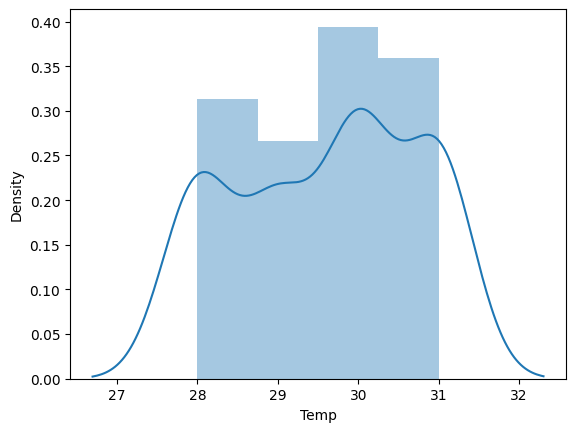

In [57]:
print(sns.distplot(dataset['Temp']))

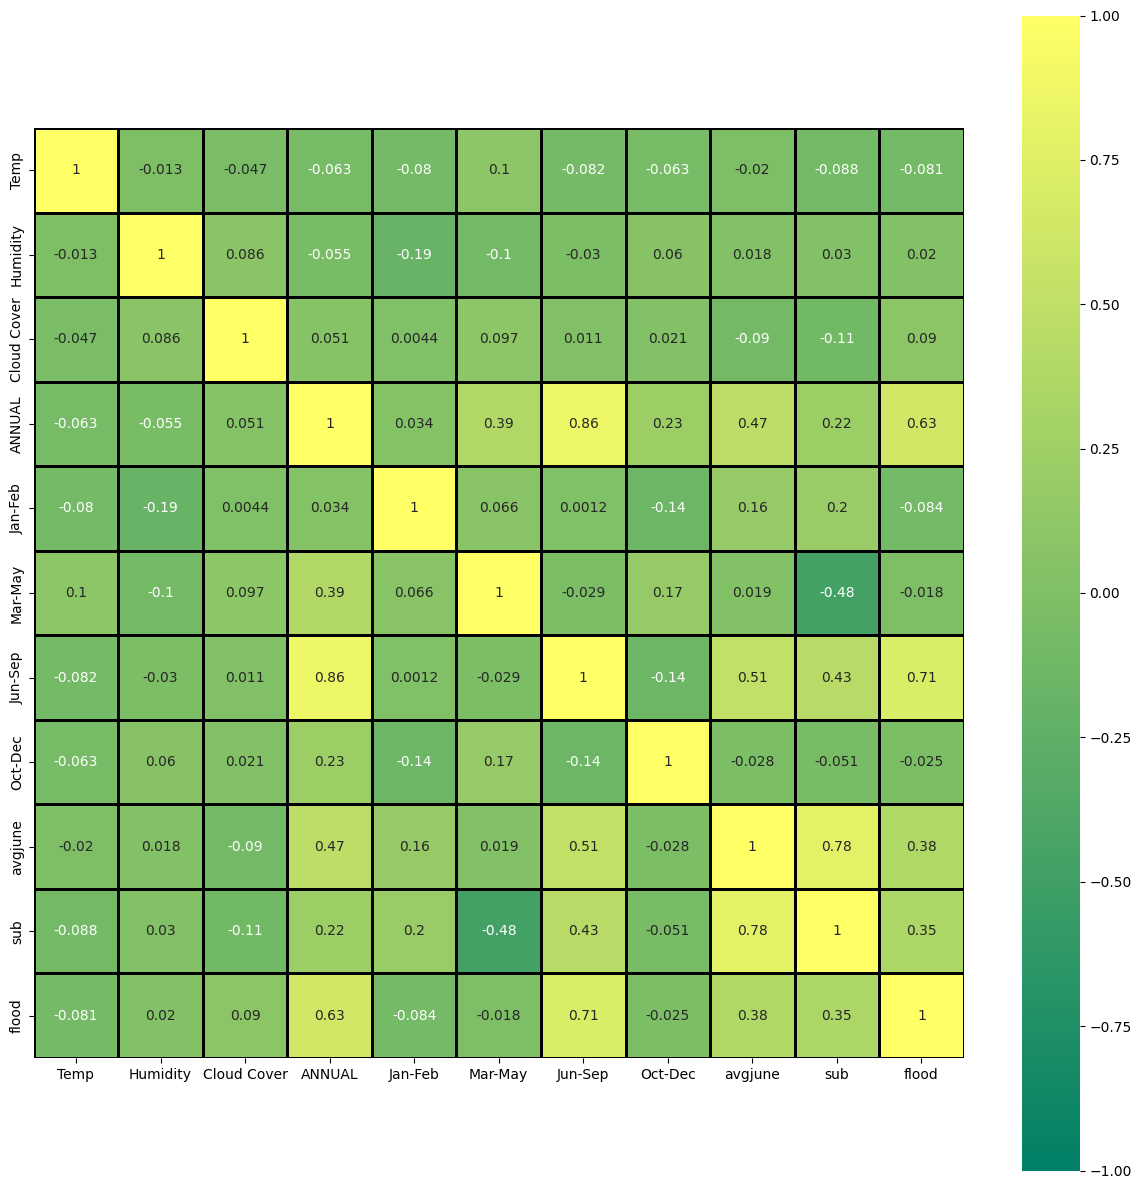

In [58]:
import seaborn as sns
fig=plt.gcf()
fig.set_size_inches (15,15)
fig=sns.heatmap(dataset.corr(),annot=True,cmap='summer',
linewidths=1,linecolor='k', square=True,
mask=False, vmin=-1, vmax=1,
cbar_kws={"orientation": "vertical"}, cbar=True)

In [59]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [60]:
dataset.isnull().sum()

,0
Temp,0
Humidity,0
Cloud Cover,0
ANNUAL,0
Jan-Feb,0
Mar-May,0
Jun-Sep,0
Oct-Dec,0
avgjune,0
sub,0


In [61]:
x=dataset.iloc[:,2:7].values

In [62]:
x=dataset.iloc[:,9:].values

In [63]:
from sklearn.model_selection import train_test_split

# Explicitly define x (features) and y (target) using column names to ensure consistency
x = dataset[['sub']].values
y = dataset['flood'].values

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=10)

In [64]:
#import Standardscaler
from sklearn.preprocessing import StandardScaler
#create object to Standardscaler class
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [65]:
from sklearn import tree
from sklearn import ensemble
from sklearn import neighbors
import xgboost

In [66]:
dtree = tree.DecisionTreeClassifier()
Rf = ensemble.RandomForestClassifier()
knn = neighbors.KNeighborsClassifier()
xgb = xgboost.XGBClassifier()

In [67]:
dtree.fit(x_train,y_train)
Rf.fit(x_train,y_train)
knn.fit(x_train,y_train)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [68]:
# This function prints the calculated results to the console for review and returns the trained model along generated predictions for future use or deployment.
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def random_forest(X_train, X_test, y_train, y_test, n_estimators=100, random_state=42):
    print("\n========== RANDOM FOREST MODEL BUILDING ==========")

    # 1. Initialize Random Forest Classifier
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
    print(f" [INFO] RandomForestClassifier initialized with n_estimators={n_estimators}, random_state={random_state}")

    # 2. Train the model
    model.fit(X_train, y_train)
    print("[INFO] Model training completed.")

    # 3. Predict on test data
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed on test data.")

    # 4. Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # 5. Display results
    print(f"\n[RESULT] Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:\n")
    print(cr)
    return model, y_pred

In [69]:
# Call the random_forest function to train and evaluate the model
rf_model, rf_y_pred = random_forest(x_train, x_test, y_train, y_test)


========== RANDOM FOREST MODEL BUILDING ==========
 [INFO] RandomForestClassifier initialized with n_estimators=100, random_state=42
[INFO] Model training completed.
[INFO] Prediction completed on test data.

[RESULT] Accuracy: 0.8276

Confusion Matrix:
[[24  2]
 [ 3  0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.92      0.91        26
           1       0.00      0.00      0.00         3

    accuracy                           0.83        29
   macro avg       0.44      0.46      0.45        29
weighted avg       0.80      0.83      0.81        29



In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def KNN(X_train, X_test, y_train, y_test):
    print("\n=========== KNN MODEL BUILDING ===========")

    # Initialize KNN classifier
    model = KNeighborsClassifier(n_neighbors=5)

    # Train the model
    model.fit(X_train, y_train)
    print("[INFO] KNN model training completed.")

    # Predict on test data
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed on test data.")

    # Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # Display results
    print(f"\n[RESULT] Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:\n")
    print(cr)

    # Return model and predictions
    return model, y_pred

# Example Usage
# knn_model, knn_pred = KNN(X_train, X_test, y_train, y_test)

In [71]:
# Call the KNN function to train and evaluate the model
knn_model, knn_y_pred = KNN(x_train, x_test, y_train, y_test)


=========== KNN MODEL BUILDING ===========
[INFO] KNN model training completed.
[INFO] Prediction completed on test data.

[RESULT] Accuracy: 0.7586

Confusion Matrix:
[[22  4]
 [ 3  0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        26
           1       0.00      0.00      0.00         3

    accuracy                           0.76        29
   macro avg       0.44      0.42      0.43        29
weighted avg       0.79      0.76      0.77        29



In [72]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import xgboost

def xgboost_model(X_train, X_test, y_train, y_test):
    print("\n========== XGBOOST MODEL BUILDING ==========")

    # Initialize XGBoost Classifier
    model = xgboost.XGBClassifier(use_label_encoder=False, eval_metric='logloss') # Added parameters to suppress warnings

    # Train the model using training data
    model.fit(X_train, y_train)
    print("[INFO] XGBoost model training completed.")

    # Predict on test data
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed on test data.")

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # Display results
    print(f"\n[RESULT] Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:\n")
    print(cr)

    # Return model and predictions
    return model, y_pred

# Example Usage
xgb_model_trained, xgb_pred = xgboost_model(x_train, x_test, y_train, y_test)


========== XGBOOST MODEL BUILDING ==========


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:28:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[INFO] XGBoost model training completed.
[INFO] Prediction completed on test data.

[RESULT] Accuracy: 0.7586

Confusion Matrix:
[[22  4]
 [ 3  0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        26
           1       0.00      0.00      0.00         3

    accuracy                           0.76        29
   macro avg       0.44      0.42      0.43        29
weighted avg       0.79      0.76      0.77        29



In [73]:
from sklearn import metrics

In [74]:
print(f"Decision Tree Accuracy: {metrics.accuracy_score(y_test, dtree.predict(x_test)):.4f}")
print(f"Random Forest Accuracy: {metrics.accuracy_score(y_test, rf_y_pred):.4f}")
print(f"KNN Accuracy: {metrics.accuracy_score(y_test, knn_y_pred):.4f}")
print(f"XGBoost Accuracy: {metrics.accuracy_score(y_test, xgb_pred):.4f}")

Decision Tree Accuracy: 0.8276
Random Forest Accuracy: 0.8276
KNN Accuracy: 0.7586
XGBoost Accuracy: 0.7586


In [75]:
print("XGBoost Confusion Matrix:")
print(metrics.confusion_matrix(y_test,xgb_pred))

XGBoost Confusion Matrix:
[[22  4]
 [ 3  0]]


In [76]:
print(metrics.accuracy_score(y_test,xgb_pred))

0.7586206896551724


In [77]:
print(metrics.precision_score(y_test, xgb_pred))

0.0


In [78]:
print(metrics.recall_score(y_test,xgb_pred))

0.0


In [79]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [80]:
import pickle
pickle.dump(rf_model,open('rdf.pkl','wb'))